# I extracted the Line ups for both teams from sofascore

In [ ]:
from curl_cffi import requests
from bs4 import BeautifulSoup

url = "https://www.sofascore.com/api/v1/event/14023998/lineups"

response = requests.get(url)
response.status_code
response.json()

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'confirmed': True, 'home': {'players': [{'player': {'name': 'Robert Sánchez', 'slug': 'robert-sanchez', 'shortName': 'R. Sánchez', 'position': 'G', 'jerseyNumber': '1', 'height': 197, 'userCount': 18911, 'gender': 'M', 'sofascoreId': 'RS1', 'country': {'alpha2': 'ES', 'alpha3': 'ESP', 'name': 'Spain', 'slug': 'spain'}, 'id': 920546, 'marketValueCurrency': 'EUR', 'dateOfBirthTimestamp': 879811200, 'proposedMarketValueRaw': {'value': 19900000, 'currency': 'EUR'}, 'fieldTranslations': {'nameTranslation': {'ar': 'روبرت سانشيز', 'bn': 'রবার্ট সানচেজ', 'hi': 'रॉबर्ट सांचेज़'}, 'shortNameTranslation': {'ar': 'ر. سانشيز', 'bn': 'আর. সানচেজ', 'hi': 'आर. सांचेज़'}}}, 'teamId': 38, 'shirtNumber': 1, 'jerseyNumber': '1', 'position': 'G', 'substitute': False, 'statistics': {'totalPass': 37, 'accuratePass': 20, 'totalLongBalls': 18, 'accurateLongBalls': 1, 'goalAssist': 0, 'accurateOwnHalfPasses': 19, 'totalOwnHalfPasses': 21, 'accurateOppositionHalfPasses': 1, 'totalOppositionHalfPasses': 16, 

# I converted it into a DataFrame

In [ ]:
import pandas as pd

home_lineup = pd.DataFrame(data["home"]["players"])
away_lineup = pd.DataFrame(data["away"]["players"])

print(home_lineup.head())

                                              player  teamId  shirtNumber  \
0  {'name': 'Robert Sánchez', 'slug': 'robert-san...      38            1   
1  {'name': 'Malo Gusto', 'slug': 'gusto-malo', '...      38           27   
2  {'name': 'Wesley Fofana', 'firstName': '', 'la...      38           29   
3  {'name': 'Jorrel Hato', 'slug': 'jorrel-hato',...      38           21   
4  {'name': 'Marc Cucurella', 'firstName': '', 'l...      38            3   

  jerseyNumber position  substitute  \
0            1        G       False   
1           27        D       False   
2           29        D       False   
3           21        D       False   
4            3        D       False   

                                          statistics captain  
0  {'totalPass': 37, 'accuratePass': 20, 'totalLo...     NaN  
1  {'totalPass': 29, 'accuratePass': 24, 'totalLo...     NaN  
2  {'totalPass': 42, 'accuratePass': 40, 'totalLo...     NaN  
3  {'totalPass': 65, 'accuratePass': 62, 'totalLo.

In [ ]:
import pandas as pd

# Extract player name
home_lineup["player_name"] = home_lineup["player"].apply(lambda x: x["name"])

# Extract stats
home_lineup["total_passes"] = home_lineup["statistics"].apply(lambda x: x.get("totalPass", 0))
home_lineup["accurate_passes"] = home_lineup["statistics"].apply(lambda x: x.get("accuratePass", 0))

# Create clean table
home_clean = home_lineup[[
    "player_name",
    "position",
    "shirtNumber",
    "substitute",
    "total_passes",
    "accurate_passes"
]]

# Add pass accuracy
home_clean["pass_accuracy"] = (
    home_clean["accurate_passes"] / home_clean["total_passes"]
) * 100

print(home_clean.head())

      player_name position  shirtNumber  substitute  total_passes  \
0  Robert Sánchez        G            1       False            37   
1      Malo Gusto        D           27       False            29   
2   Wesley Fofana        D           29       False            42   
3     Jorrel Hato        D           21       False            65   
4  Marc Cucurella        D            3       False            23   

   accurate_passes  pass_accuracy  
0               20      54.054054  
1               24      82.758621  
2               40      95.238095  
3               62      95.384615  
4               20      86.956522  


/tmp/ipykernel_19570/2428890091.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home_clean["pass_accuracy"] = (


In [ ]:
home_clean.head()

,player_name,position,shirtNumber,substitute,total_passes,accurate_passes,pass_accuracy
0,Robert Sánchez,G,1,False,37,20,54.054054
1,Malo Gusto,D,27,False,29,24,82.758621
2,Wesley Fofana,D,29,False,42,40,95.238095
3,Jorrel Hato,D,21,False,65,62,95.384615
4,Marc Cucurella,D,3,False,23,20,86.956522


# Player Influence (Who controls the game)

In [ ]:
home_clean.sort_values(by="total_passes", ascending=False)

,player_name,position,shirtNumber,substitute,total_passes,accurate_passes,pass_accuracy
3,Jorrel Hato,D,21,False,65,62,95.384615
6,Moisés Caicedo,M,25,False,47,38,80.851064
2,Wesley Fofana,D,29,False,42,40,95.238095
0,Robert Sánchez,G,1,False,37,20,54.054054
8,Cole Palmer,M,10,False,36,33,91.666667
5,Andrey Santos,M,17,False,34,29,85.294118
1,Malo Gusto,D,27,False,29,24,82.758621
11,Roméo Lavia,M,45,True,25,21,84.000000
4,Marc Cucurella,D,3,False,23,20,86.956522
9,Pedro Neto,M,7,False,22,19,86.363636


# Team Total Passes

In [ ]:
team_total_passes = home_clean["total_passes"].sum()
print(team_total_passes)

407


# Team accurate passes

In [ ]:
team_accurate_passes = home_clean["accurate_passes"].sum()
print(team_accurate_passes)

342


# Away line up

In [ ]:
away_lineup = pd.DataFrame(data["away"]["players"])
print(away_lineup.head())

                                              player  teamId  shirtNumber  \
0  {'name': 'Gianluigi Donnarumma', 'slug': 'gian...      17           25   
1  {'name': 'Matheus Nunes', 'firstName': '', 'la...      17           27   
2  {'name': 'Abdukodir Khusanov', 'slug': 'abduko...      17           45   
3  {'name': 'Marc Guéhi', 'slug': 'marc-guehi', '...      17           15   
4  {'name': 'Nico O'Reilly', 'firstName': 'Nico',...      17           33   

  jerseyNumber position  substitute  \
0           25        G       False   
1           27        D       False   
2           45        D       False   
3           15        D       False   
4           33        D       False   

                                          statistics captain  
0  {'totalPass': 26, 'accuratePass': 24, 'totalLo...     NaN  
1  {'totalPass': 69, 'accuratePass': 65, 'totalLo...     NaN  
2  {'totalPass': 77, 'accuratePass': 72, 'totalLo...     NaN  
3  {'totalPass': 102, 'accuratePass': 101, 'total.

In [ ]:
import pandas as pd

# Extract player name
away_lineup["player_name"] = away_lineup["player"].apply(lambda x: x["name"])

# Extract stats
away_lineup["total_passes"] = away_lineup["statistics"].apply(lambda x: x.get("totalPass", 0))
away_lineup["accurate_passes"] = away_lineup["statistics"].apply(lambda x: x.get("accuratePass", 0))

# Create clean table
away_clean = away_lineup[[
    "player_name",
    "position",
    "shirtNumber",
    "substitute",
    "total_passes",
    "accurate_passes"
]]

# Add pass accuracy
away_clean["pass_accuracy"] = (
    away_clean["accurate_passes"] / away_clean["total_passes"]
) * 100

print(away_clean.head())

            player_name position  shirtNumber  substitute  total_passes  \
0  Gianluigi Donnarumma        G           25       False            26   
1         Matheus Nunes        D           27       False            69   
2    Abdukodir Khusanov        D           45       False            77   
3            Marc Guéhi        D           15       False           102   
4         Nico O'Reilly        D           33       False            44   

   accurate_passes  pass_accuracy  
0               24      92.307692  
1               65      94.202899  
2               72      93.506494  
3              101      99.019608  
4               41      93.181818  


/tmp/ipykernel_19570/4252244154.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  away_clean["pass_accuracy"] = (


In [ ]:
away_clean.head()

,player_name,position,shirtNumber,substitute,total_passes,accurate_passes,pass_accuracy
0,Gianluigi Donnarumma,G,25,False,26,24,92.307692
1,Matheus Nunes,D,27,False,69,65,94.202899
2,Abdukodir Khusanov,D,45,False,77,72,93.506494
3,Marc Guéhi,D,15,False,102,101,99.019608
4,Nico O'Reilly,D,33,False,44,41,93.181818


# Player Influence (Who controls the game)

In [ ]:
away_clean.sort_values(by="total_passes", ascending=False)

,player_name,position,shirtNumber,substitute,total_passes,accurate_passes,pass_accuracy
3,Marc Guéhi,D,15,False,102,101,99.019608
6,Rodri,M,16,False,102,95,93.137255
2,Abdukodir Khusanov,D,45,False,77,72,93.506494
5,Bernardo Silva,M,20,False,73,62,84.931507
1,Matheus Nunes,D,27,False,69,65,94.202899
8,Rayan Cherki,M,10,False,59,53,89.830508
4,Nico O'Reilly,D,33,False,44,41,93.181818
9,Jérémy Doku,M,11,False,38,34,89.473684
7,Antoine Semenyo,M,42,False,33,29,87.878788
0,Gianluigi Donnarumma,G,25,False,26,24,92.307692


# Team Total Passes

In [ ]:
team_total_passes = away_clean["total_passes"].sum()
print(team_total_passes)

685


# Team accurate passes

In [ ]:
team_accurate_passes = away_clean["accurate_passes"].sum()
print(team_accurate_passes)

627


# I extracted the shot data from sofascore

In [ ]:
from curl_cffi import requests
from bs4 import BeautifulSoup

url = "https://www.sofascore.com/api/v1/event/14023998/shotmap"

response = requests.get(url)
response.status_code
response.json()

print(response.status_code)
print(response.json())

data = response.json()
print(data.keys())

200
{'shotmap': [{'player': {'name': 'Erling Haaland', 'slug': 'erling-haaland', 'shortName': 'E. Haaland', 'position': 'F', 'jerseyNumber': '9', 'userCount': 893091, 'gender': 'M', 'id': 839956, 'fieldTranslations': {'nameTranslation': {'ar': 'إيرلينغ هالاند', 'bn': 'এরলিং হালান্ড', 'hi': 'एर्लिंग हालैंड'}, 'shortNameTranslation': {'ar': 'إ. هالاند', 'bn': 'ই. হালান্ড', 'hi': 'ई. हालैंड'}}}, 'isHome': False, 'shotType': 'save', 'situation': 'assisted', 'playerCoordinates': {'x': 9.5, 'y': 39.2, 'z': 0}, 'bodyPart': 'head', 'goalMouthLocation': 'low-right', 'goalMouthCoordinates': {'x': 0, 'y': 45.8, 'z': 10.1}, 'blockCoordinates': {'x': 1.1, 'y': 48.7, 'z': 0}, 'xg': 0.022336909547448, 'xgot': 0.28080525994301, 'goalkeeper': {'name': 'Robert Sánchez', 'slug': 'robert-sanchez', 'shortName': 'R. Sánchez', 'position': 'G', 'jerseyNumber': '1', 'userCount': 18911, 'gender': 'M', 'sofascoreId': 'RS1', 'id': 920546, 'fieldTranslations': {'nameTranslation': {'ar': 'روبرت سانشيز', 'bn': 'রবার

# I converted it into a DataFrame

In [ ]:
import pandas as pd

shots = pd.DataFrame(data["shotmap"])

print(shots.head())

                                              player  isHome shotType  \
0  {'name': 'Erling Haaland', 'slug': 'erling-haa...   False     save   
1  {'name': 'Erling Haaland', 'slug': 'erling-haa...   False    block   
2  {'name': 'Erling Haaland', 'slug': 'erling-haa...   False     miss   
3  {'name': 'Cole Palmer', 'slug': 'cole-palmer',...    True     save   
4  {'name': 'Marc Cucurella', 'firstName': '', 'l...    True     save   

   situation               playerCoordinates   bodyPart goalMouthLocation  \
0   assisted   {'x': 9.5, 'y': 39.2, 'z': 0}       head         low-right   
1   assisted  {'x': 14.4, 'y': 46.6, 'z': 0}  left-foot         low-right   
2     corner   {'x': 4.1, 'y': 39.9, 'z': 0}       head             right   
3  free-kick  {'x': 18.4, 'y': 61.8, 'z': 0}  left-foot          low-left   
4   assisted   {'x': 4.2, 'y': 44.5, 'z': 0}       head          low-left   

             goalMouthCoordinates               blockCoordinates        xg  \
0  {'x': 0, 'y': 45.

In [ ]:
import pandas as pd

shots_df = pd.DataFrame({
    "player": [s["player"]["name"] for s in data["shotmap"]],
    "team_home": [s["isHome"] for s in data["shotmap"]],
    "shot_type": [s["shotType"] for s in data["shotmap"]],
    "situation": [s["situation"] for s in data["shotmap"]],
    "body_part": [s["bodyPart"] for s in data["shotmap"]],
    "x": [s["playerCoordinates"]["x"] for s in data["shotmap"]],
    "y": [s["playerCoordinates"]["y"] for s in data["shotmap"]],
    "xg": [s.get("xg", 0) for s in data["shotmap"]],  # Use 0 if xG is missing
    "minute": [s["time"] for s in data["shotmap"]]
})

print(shots_df.head())

           player  team_home shot_type  situation  body_part     x     y  \
0  Erling Haaland      False      save   assisted       head   9.5  39.2   
1  Erling Haaland      False     block   assisted  left-foot  14.4  46.6   
2  Erling Haaland      False      miss     corner       head   4.1  39.9   
3     Cole Palmer       True      save  free-kick  left-foot  18.4  61.8   
4  Marc Cucurella       True      save   assisted       head   4.2  44.5   

         xg  minute  
0  0.022337      90  
1  0.149189      90  
2  0.085186      87  
3  0.100786      85  
4  0.524230      83  


In [ ]:
shots_df.head()

,player,team_home,shot_type,situation,body_part,x,y,xg,minute
0,Erling Haaland,False,save,assisted,head,9.5,39.2,0.022337,90
1,Erling Haaland,False,block,assisted,left-foot,14.4,46.6,0.149189,90
2,Erling Haaland,False,miss,corner,head,4.1,39.9,0.085186,87
3,Cole Palmer,True,save,free-kick,left-foot,18.4,61.8,0.100786,85
4,Marc Cucurella,True,save,assisted,head,4.2,44.5,0.524230,83


In [50]:
shots_df.to_csv("shots6.csv", index=False)
from google.colab import files
files.download("shots6.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Basic Match Summary

# Total shots per team






In [ ]:
shots_df.groupby('team_home')['shot_type'].count()

,shot_type
team_home,
False,18
True,12


In [ ]:
shots_df.groupby(['team_home', 'shot_type']).size().unstack(fill_value=0)

shot_type,block,goal,miss,save
team_home,,,,
False,6,3,4,5
True,5,0,4,3


# shots efficiency

In [ ]:
import pandas as pd

# Sample data
data = {
    'team_home': [False, True],
    'block':[6, 5],
    'miss': [4, 4],
    'save': [5, 3],
    'goal': [3, 0]
}

df = pd.DataFrame(data)
df.set_index('team_home', inplace=True)

# Calculate total shots
df['total_shots'] = df.sum(axis=1)

# Calculate shots on target (saves)
df['shots_on_target'] = df['save']+ df['goal']

# Shooting accuracy %
df['shooting_accuracy'] = (df['shots_on_target'] / df['total_shots'] * 100).round(2)

print(df[['total_shots', 'shots_on_target', 'shooting_accuracy']])

           total_shots  shots_on_target  shooting_accuracy
team_home                                                 
False               18                8              44.44
True                12                3              25.00


# Average Shot Distance

In [ ]:
shots_df.groupby('team_home')[['x','y']].mean()

,x,y
team_home,,
False,12.638889,48.733333
True,13.225000,42.825000


# Average distance to goal

In [ ]:
import numpy as np

# Assuming goal is at x=100, y=50
shots_df['distance_to_goal'] = np.sqrt((shots_df['x'])**2 + (shots_df['y'] - 50)**2)

shots_df.groupby('team_home')['distance_to_goal'].mean()

,distance_to_goal
team_home,
False,16.785043
True,19.207837


# Total shots per player

In [ ]:
shots_per_player = shots_df.groupby("player").size().reset_index(name="Total_Shots")
print(shots_per_player)

                player  Total_Shots
0   Abdukodir Khusanov            1
1        Andrey Santos            1
2      Antoine Semenyo            5
3       Bernardo Silva            2
4          Cole Palmer            4
5       Erling Haaland            4
6           João Pedro            3
7          Jérémy Doku            2
8       Marc Cucurella            2
9           Marc Guéhi            1
10      Moisés Caicedo            1
11       Nico O'Reilly            1
12          Pedro Neto            1
13        Rayan Cherki            2


# Dangerous Shooters

In [ ]:
shots_df.groupby("player",)["xg"].sum().sort_values(ascending=False)

,xg
player,
Erling Haaland,0.576537
Marc Cucurella,0.546272
Nico O'Reilly,0.427784
Marc Guéhi,0.327073
Cole Palmer,0.301982
Antoine Semenyo,0.289728
Bernardo Silva,0.253153
João Pedro,0.222255
Rayan Cherki,0.204634


In [ ]:
import pandas as pd

data = {
    "player": [
        "Marc Cucurella",
        "Erling Haaland",
        "Nico O'Reilly",
        "Antoine Semenyo",
        "Cole Palmer",
        "Marc Guéhi",
        "Bernardo Silva",
        "João Pedro",
        "Rayan Cherki",
        "Jérémy Doku",
        "Andrey Santos",
        "Pedro Neto",
        "Moisés Caicedo",
        "Abdukodir Khusanov"
    ],
    "xg": [
        0.540628,
        0.401729,
        0.389631,
        0.293752,
        0.282527,
        0.264430,
        0.253153,
        0.184633,
        0.137135,
        0.131291,
        0.053382,
        0.046711,
        0.033560,
        0.019355
    ]
}

df_players = pd.DataFrame(data)

# Sort for better analysis (optional)
df_players = df_players.sort_values(by="xg", ascending=False)

df_players

,player,xg
0,Marc Cucurella,0.540628
1,Erling Haaland,0.401729
2,Nico O'Reilly,0.389631
3,Antoine Semenyo,0.293752
4,Cole Palmer,0.282527
5,Marc Guéhi,0.264430
6,Bernardo Silva,0.253153
7,João Pedro,0.184633
8,Rayan Cherki,0.137135
9,Jérémy Doku,0.131291


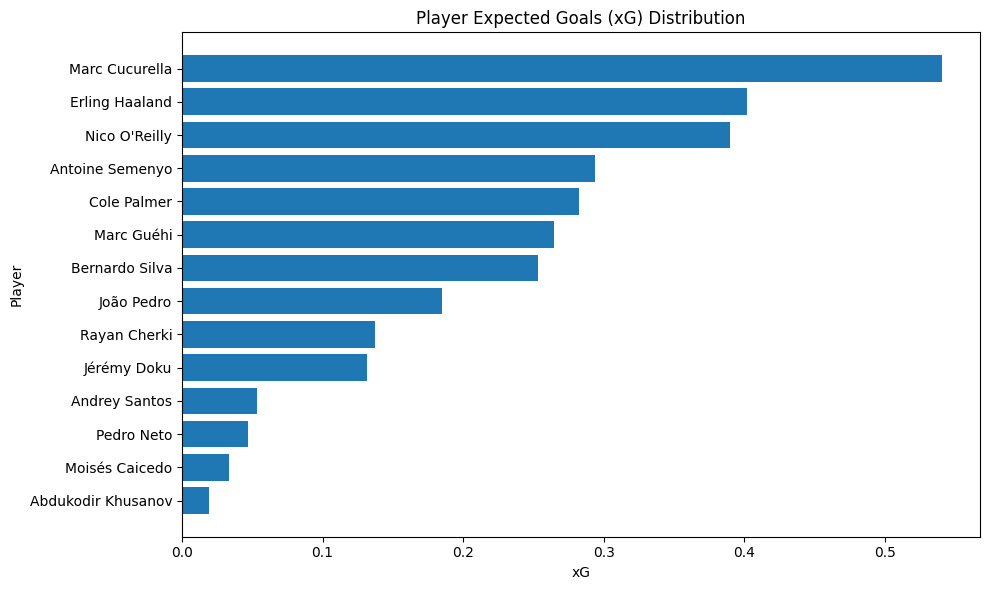

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Sort values
df_players_sorted = df_players.sort_values("xg", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(df_players_sorted["player"], df_players_sorted["xg"])

plt.title("Player Expected Goals (xG) Distribution")
plt.xlabel("xG")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

# Team total Expected goals (xG)

In [ ]:
shots_df.groupby("team_home")["xg"].sum()

,xg
team_home,
False,2.290401
True,1.253964


In [ ]:
import pandas as pd

data = {
    "team_home": [False, True],
    "xg": [1.890475,1.141440]
}

df_team_xg = pd.DataFrame(data)

# Optional: map team labels for clarity
df_team_xg["team"] = df_team_xg["team_home"].map({
    True: "Chelsea",
    False: "Manchester City"
})

# Reorder columns
df_team_xg = df_team_xg[["team", "team_home", "xg"]]

print(df_team_xg)

              team  team_home        xg
0  Manchester City      False  1.890475
1          Chelsea       True  1.141440


In [ ]:
# Example: add actual goals for efficiency
df_team_xg["goals"] = [3, 0]

# Calculate finishing efficiency
df_team_xg["xg_per_goal"] = df_team_xg["xg"] / df_team_xg["goals"]

print(df_team_xg)

              team  team_home        xg  goals  xg_per_goal
0  Manchester City      False  1.890475      3     0.630158
1          Chelsea       True  1.141440      0          inf


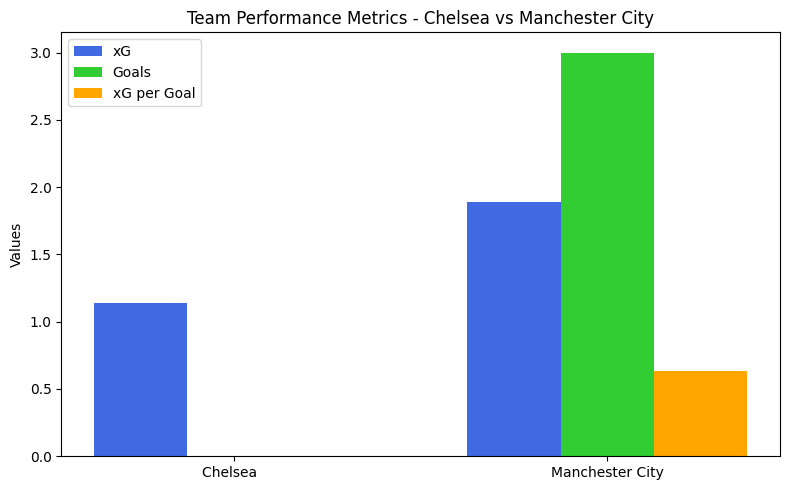

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

teams = ["Chelsea  ", "Manchester City"]
xg = [1.141440, 1.890475]
goals = [0, 3]
xg_per_goal = [0,  0.630158]

x = np.arange(len(teams))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, xg, width, label="xG", color="royalblue")
plt.bar(x, goals, width, label="Goals", color="limegreen")
plt.bar(x + width, xg_per_goal, width, label="xG per Goal", color="orange")
plt.xticks(x, teams)
plt.ylabel("Values")
plt.title("Team Performance Metrics - Chelsea vs Manchester City")
plt.legend()
plt.tight_layout()
plt.show()

# Comparing shot and Expected goal

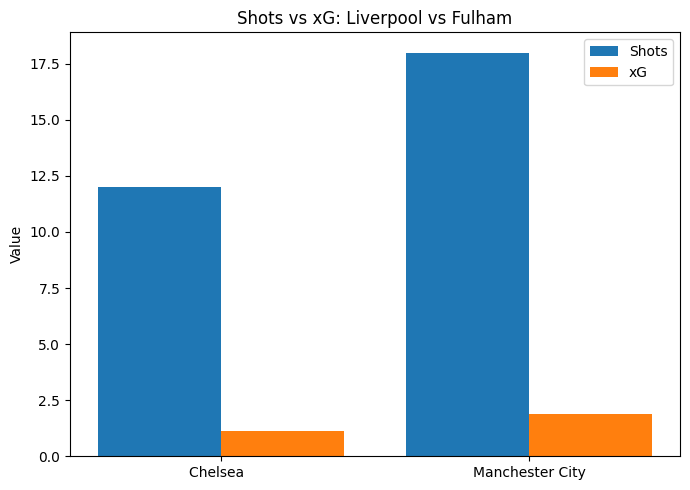

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Team": ["Chelsea  ", "Manchester City"],
    "Shots": [12, 18],
    "xG": [1.141440, 1.890475]
}

df = pd.DataFrame(data)

x = range(len(df))

plt.figure(figsize=(7,5))

plt.bar(x, df["Shots"], width=0.4, label="Shots")
plt.bar([i + 0.4 for i in x], df["xG"], width=0.4, label="xG")

plt.xticks([i + 0.2 for i in x], df["Team"])
plt.ylabel("Value")
plt.title("Shots vs xG: Liverpool vs Fulham")
plt.legend()

plt.tight_layout()
plt.show()

# Number of situation per Team

In [ ]:
situation_counts= shots_df.groupby("team_home")["situation"].value_counts()
print(situation_counts)

team_home  situation 
False      assisted      12
           regular        4
           corner         2
True       assisted       8
           fast-break     1
           free-kick      1
           regular        1
           set-piece      1
Name: count, dtype: int64


In [ ]:
import pandas as pd

data = {
    "Team": [
        "Manchester City", "Manchester City", "Manchester City",
        "Chelsea", "Chelsea", "Chelsea", "Chelsea", "Chelsea"
    ],
    "Situation": [
        "assisted", "regular", "corner",
        "assisted", "fast-break", "free-kick","regular","set-piece"
    ],
    "Shots": [
        12, 4, 2,
        8, 1, 1, 1, 1
    ]
}

df_situations = pd.DataFrame(data)

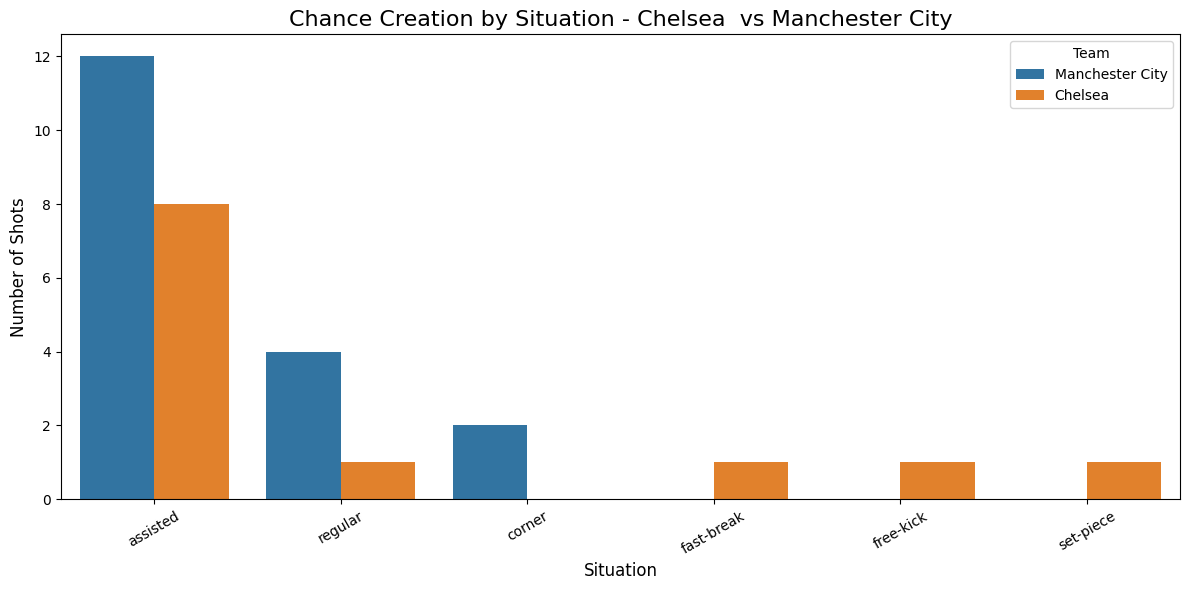

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_situations,
    x="Situation",
    y="Shots",
    hue="Team"
)

plt.title("Chance Creation by Situation - Chelsea  vs Manchester City", fontsize=16)
plt.xlabel("Situation", fontsize=12)
plt.ylabel("Number of Shots", fontsize=12)

plt.xticks(rotation=30)
plt.legend(title="Team")

plt.tight_layout()
plt.show()

# Number of situation by player

In [ ]:
situation_counts= shots_df.groupby("player")["situation"].value_counts()
print(situation_counts)

player              situation 
Abdukodir Khusanov  assisted      1
Andrey Santos       set-piece     1
Antoine Semenyo     assisted      3
                    regular       2
Bernardo Silva      assisted      1
                    regular       1
Cole Palmer         assisted      2
                    fast-break    1
                    free-kick     1
Erling Haaland      assisted      3
                    corner        1
João Pedro          assisted      2
                    regular       1
Jérémy Doku         assisted      1
                    regular       1
Marc Cucurella      assisted      2
Marc Guéhi          corner        1
Moisés Caicedo      assisted      1
Nico O'Reilly       assisted      1
Pedro Neto          assisted      1
Rayan Cherki        assisted      2
Name: count, dtype: int64


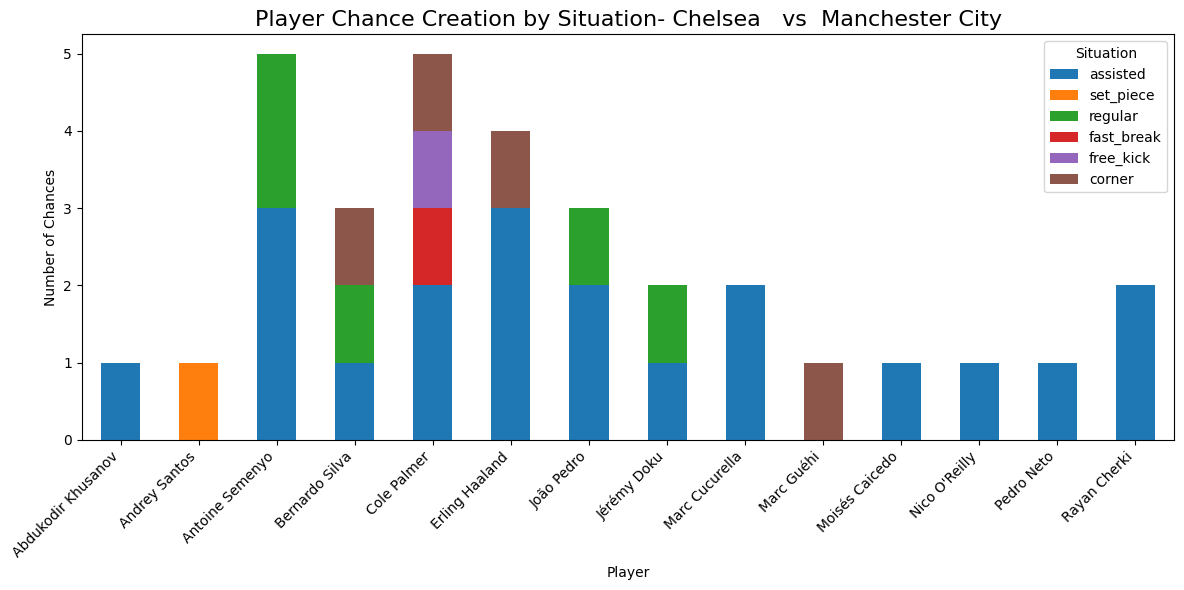

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reconstructed data (from your player-situation list)
data = {
    "player": [
        "Abdukodir Khusanov",
        "Andrey Santos",
        "Antoine Semenyo",
        "Bernardo Silva",
        "Cole Palmer",
        "Erling Haaland",
        "João Pedro",
        "Jérémy Doku",
        "Marc Cucurella",
        "Marc Guéhi",
        "Moisés Caicedo",
        "Nico O'Reilly",
        "Pedro Neto",
        "Rayan Cherki"
    ],
    "assisted": [
        1, 0, 3, 1, 2, 3, 2, 1, 2, 0, 1, 1, 1, 2
    ],
    "set_piece": [
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ],
    "regular": [
        0, 0, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0
    ],
    "fast_break": [
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ],
    "free_kick": [
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ],
    "corner": [
        0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0
    ]
}

df = pd.DataFrame(data).set_index("player")

# Plot
fig, ax = plt.subplots(figsize=(12,6))
df.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Player Chance Creation by Situation- Chelsea   vs  Manchester City", fontsize=16)
ax.set_ylabel("Number of Chances")
ax.set_xlabel("Player")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Situation")
plt.tight_layout()
plt.show()

# Shot outcome per player and position

In [ ]:
shots_counts= shots_df.groupby(["team_home","player", "x","y","xg"])["shot_type"].value_counts().reset_index(name="shots")
print(shots_counts)

    team_home              player     x     y        xg shot_type  shots
0       False  Abdukodir Khusanov  28.1  55.6  0.027816      miss      1
1       False     Antoine Semenyo   8.4  62.7  0.077062     block      1
2       False     Antoine Semenyo  11.1  70.9  0.035154      save      1
3       False     Antoine Semenyo  18.5  32.5  0.041636      miss      1
4       False     Antoine Semenyo  19.4  49.5  0.061314     block      1
5       False     Antoine Semenyo  21.3  42.7  0.074563      save      1
6       False      Bernardo Silva   7.8  46.1  0.183850      save      1
7       False      Bernardo Silva  11.9  48.1  0.069303     block      1
8       False      Erling Haaland   4.1  39.9  0.085186      miss      1
9       False      Erling Haaland   9.5  39.2  0.022337      save      1
10      False      Erling Haaland  11.3  39.3  0.319824      miss      1
11      False      Erling Haaland  14.4  46.6  0.149189     block      1
12      False         Jérémy Doku   9.7  43.0  0.09

In [ ]:
shots_counts= shots_df.groupby(["team_home","player","xg","situation"])["shot_type"].value_counts().reset_index(name="shots")
print(shots_counts)

    team_home              player        xg   situation shot_type  shots
0       False  Abdukodir Khusanov  0.027816    assisted      miss      1
1       False     Antoine Semenyo  0.035154    assisted      save      1
2       False     Antoine Semenyo  0.041636     regular      miss      1
3       False     Antoine Semenyo  0.061314    assisted     block      1
4       False     Antoine Semenyo  0.074563     regular      save      1
5       False     Antoine Semenyo  0.077062    assisted     block      1
6       False      Bernardo Silva  0.069303     regular     block      1
7       False      Bernardo Silva  0.183850    assisted      save      1
8       False      Erling Haaland  0.022337    assisted      save      1
9       False      Erling Haaland  0.085186      corner      miss      1
10      False      Erling Haaland  0.149189    assisted     block      1
11      False      Erling Haaland  0.319824    assisted      miss      1
12      False         Jérémy Doku  0.088257    assi

# Shot Map

In [ ]:
pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.7 MB/s eta 0:00:00


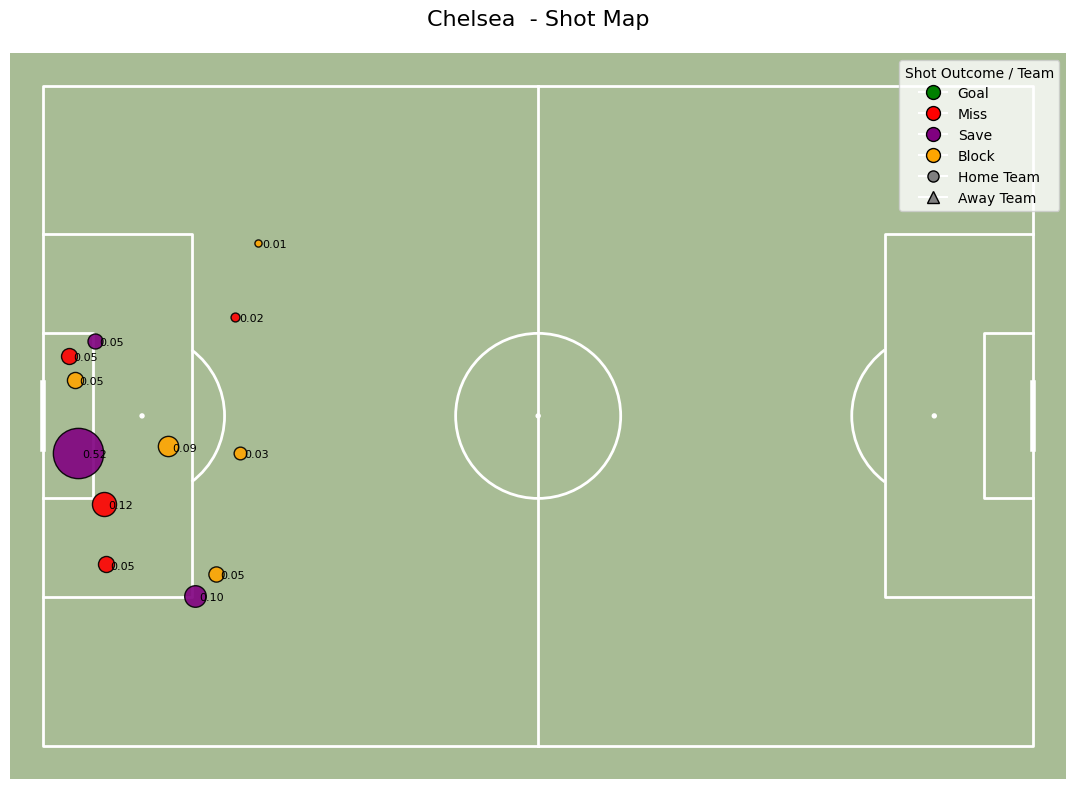

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D
data = {
    "team_home": [
        True, True, True, True, True, True, True,
        True, True, True, True, True
    ],
    "player": [
        "Andrey Santos",
        "Cole Palmer",
        "Cole Palmer",
        "Cole Palmer",
        "Cole Palmer",
        "João Pedro",
        "João Pedro",
        "João Pedro",
        "Marc Cucurella",
        "Marc Cucurella",
        "Moisés Caicedo",
        "Pedro Neto"
    ],
    "x": [
        7.6, 3.2, 15.2, 18.4, 21.0,
        3.9, 7.4, 26.1,
        4.2, 23.3,
        23.9, 6.3
    ],
    "y": [
        58.0, 32.7, 43.7, 61.8, 59.1,
        35.6, 50.7, 19.0,
        44.5, 28.0,
        44.5, 30.9
    ],
    "xg": [
        0.053382, 0.052809, 0.085280, 0.096382, 0.048056,
        0.053915, 0.120135, 0.010583,
        0.524230, 0.016398,
        0.033560, 0.046711
    ],
    "shot_type": [
        "miss",
        "miss",
        "block",
        "save",
        "block",
        "block",
        "miss",
        "block",
        "save",
        "miss",
        "block",
        "save"
    ],
    "shots": [1] * 12
}

df_shots = pd.DataFrame(data)

# --------------------------
# Create Pitch
# --------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,8))

# --------------------------
# Define colors for shot outcomes
# --------------------------
shot_colors = {'goal':'green', 'miss':'red', 'save':'purple','block':'orange',}

# --------------------------
# Plot Shots
# --------------------------
for idx, row in df_shots.iterrows():
    home = row['team_home']
    marker_type = 'o' if home else '^'  # circle for home, triangle for away
    color = shot_colors.get(row['shot_type'], 'black')
    size = row['xg'] * 2500  # scale by xG

    ax.scatter(row['x'], row['y'], color=color, s=size, marker=marker_type,
               edgecolors='black', alpha=0.9, zorder=5)

    # Optional: show xG next to marker
    ax.text(row['x']+0.5, row['y']+0.5, f"{row['xg']:.2f}", fontsize=8, color='black', zorder=6)

# --------------------------
# Legends
# --------------------------
shot_elements = [Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
                        markerfacecolor=v, markersize=10, markeredgecolor='black')
                 for k,v in shot_colors.items()]

team_elements = [
    Line2D([0], [0], marker='o', color='w', label='Home Team', markerfacecolor='grey',
           markersize=8, markeredgecolor='black'),
    Line2D([0], [0], marker='^', color='w', label='Away Team', markerfacecolor='grey',
           markersize=8, markeredgecolor='black')
]

ax.legend(handles=shot_elements + team_elements, title='Shot Outcome / Team', loc='upper right')
ax.set_title("Chelsea  - Shot Map", fontsize=16, pad=20)

plt.show()

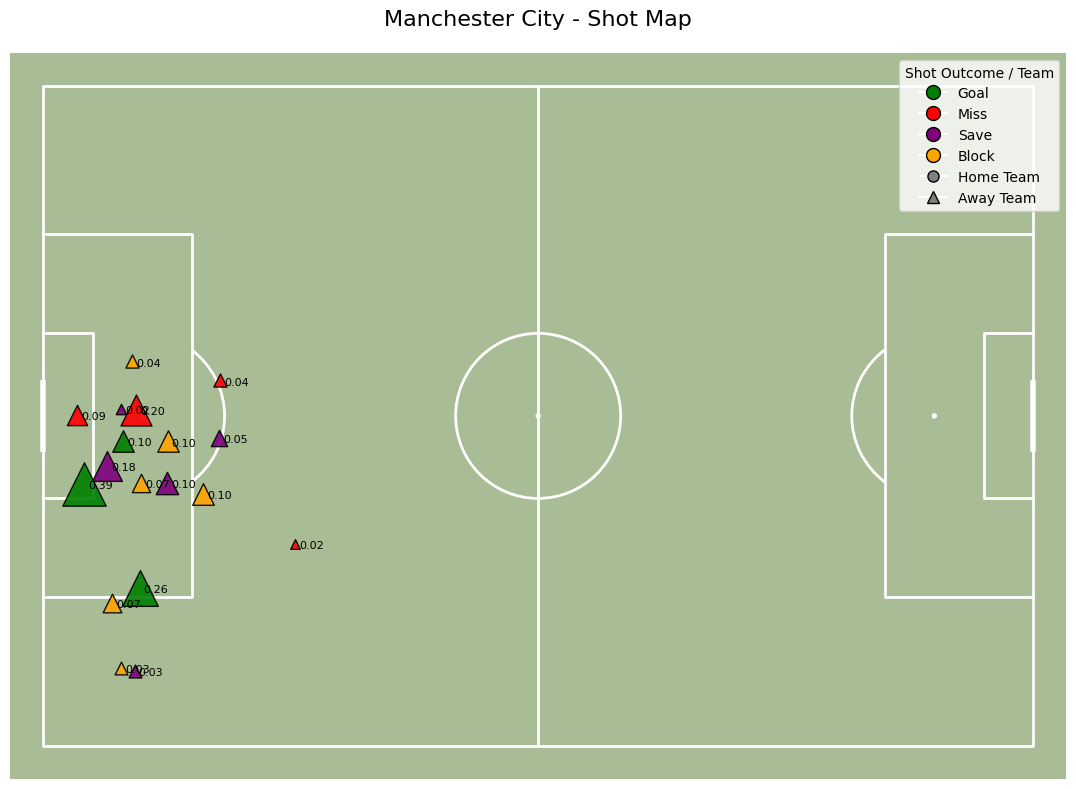

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D
data = {
    "team_home": [
        False, False, False, False, False, False,
        False, False, False, False, False, False,
        False, False, False, False, False, False
    ],
    "player": [
        "Abdukodir Khusanov",
        "Antoine Semenyo",
        "Antoine Semenyo",
        "Antoine Semenyo",
        "Antoine Semenyo",
        "Antoine Semenyo",
        "Bernardo Silva",
        "Bernardo Silva",
        "Erling Haaland",
        "Erling Haaland",
        "Erling Haaland",
        "Erling Haaland",
        "Jérémy Doku",
        "Jérémy Doku",
        "Marc Guéhi",
        "Nico O'Reilly",
        "Rayan Cherki",
        "Rayan Cherki"
    ],
    "x": [
        30.5, 8.4, 11.1, 19.4, 21.3, 21.5,
        7.8, 11.9,
        4.1, 9.5, 11.3, 15.1,
        9.7, 10.8,
        11.7, 5.0,
        9.5, 15.0
    ],
    "y": [
        55.5, 62.7, 70.9, 49.5, 42.7, 35.7,
        46.1, 48.1,
        39.9, 39.2, 39.3, 43.1,
        43.0, 33.4,
        60.9, 48.2,
        70.5, 48.1
    ],
    "xg": [
        0.019355, 0.072118, 0.034475, 0.096668, 0.054900, 0.035592,
        0.183850, 0.069303,
        0.085186, 0.022337, 0.198855, 0.095351,
        0.095419, 0.035872,
        0.264430, 0.389631,
        0.033630, 0.103504
    ],
    "shot_type": [
        "miss", "block", "save", "block", "save", "miss",
        "save", "block",
        "miss", "save", "miss", "block",
        "goal", "block",
        "goal", "goal",
        "block", "save"
    ],
    "shots": [1] * 18
}

df_shots = pd.DataFrame(data)

# --------------------------
# Create Pitch
# --------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,8))

# --------------------------
# Define colors for shot outcomes
# --------------------------
shot_colors = {'goal':'green', 'miss':'red', 'save':'purple','block':'orange',}

# --------------------------
# Plot Shots
# --------------------------
for idx, row in df_shots.iterrows():
    home = row['team_home']
    marker_type = 'o' if home else '^'  # circle for home, triangle for away
    color = shot_colors.get(row['shot_type'], 'black')
    size = row['xg'] * 2500  # scale by xG

    ax.scatter(row['x'], row['y'], color=color, s=size, marker=marker_type,
               edgecolors='black', alpha=0.9, zorder=5)

    # Optional: show xG next to marker
    ax.text(row['x']+0.5, row['y']+0.5, f"{row['xg']:.2f}", fontsize=8, color='black', zorder=6)

# --------------------------
# Legends
# --------------------------
shot_elements = [Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
                        markerfacecolor=v, markersize=10, markeredgecolor='black')
                 for k,v in shot_colors.items()]

team_elements = [
    Line2D([0], [0], marker='o', color='w', label='Home Team', markerfacecolor='grey',
           markersize=8, markeredgecolor='black'),
    Line2D([0], [0], marker='^', color='w', label='Away Team', markerfacecolor='grey',
           markersize=8, markeredgecolor='black')
]

ax.legend(handles=shot_elements + team_elements, title='Shot Outcome / Team', loc='upper right')
ax.set_title("Manchester City - Shot Map", fontsize=16, pad=20)

plt.show()

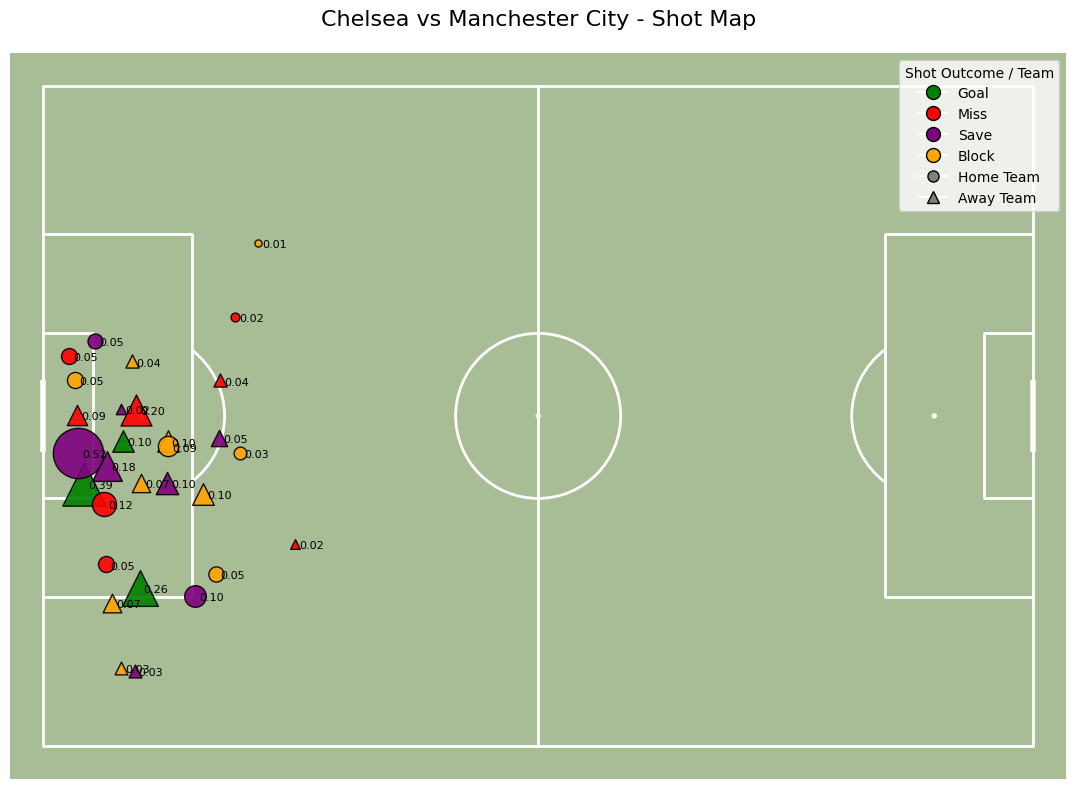

In [ ]:
import pandas as pd

data = {
    "team_home": [
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False,
        True, True, True, True, True, True, True, True, True, True, True, True
    ],
    "player": [
        "Abdukodir Khusanov",
        "Antoine Semenyo",
        "Antoine Semenyo",
        "Antoine Semenyo",
        "Antoine Semenyo",
        "Antoine Semenyo",
        "Bernardo Silva",
        "Bernardo Silva",
        "Erling Haaland",
        "Erling Haaland",
        "Erling Haaland",
        "Erling Haaland",
        "Jérémy Doku",
        "Jérémy Doku",
        "Marc Guéhi",
        "Nico O'Reilly",
        "Rayan Cherki",
        "Rayan Cherki",
        "Andrey Santos",
        "Cole Palmer",
        "Cole Palmer",
        "Cole Palmer",
        "Cole Palmer",
        "João Pedro",
        "João Pedro",
        "João Pedro",
        "Marc Cucurella",
        "Marc Cucurella",
        "Moisés Caicedo",
        "Pedro Neto"
    ],
    "x": [
        30.5, 8.4, 11.1, 19.4, 21.3, 21.5, 7.8, 11.9,
        4.1, 9.5, 11.3, 15.1,
        9.7, 10.8,
        11.7, 5.0,
        9.5, 15.0,
        7.6,
        3.2, 15.2, 18.4, 21.0,
        3.9, 7.4, 26.1,
        4.2, 23.3,
        23.9,
        6.3
    ],
    "y": [
        55.5, 62.7, 70.9, 49.5, 42.7, 35.7, 46.1, 48.1,
        39.9, 39.2, 39.3, 43.1,
        43.0, 33.4,
        60.9, 48.2,
        70.5, 48.1,
        58.0,
        32.7, 43.7, 61.8, 59.1,
        35.6, 50.7, 19.0,
        44.5, 28.0,
        44.5,
        30.9
    ],
    "xg": [
        0.019355, 0.072118, 0.034475, 0.096668, 0.054900, 0.035592,
        0.183850, 0.069303,
        0.085186, 0.022337, 0.198855, 0.095351,
        0.095419, 0.035872,
        0.264430, 0.389631,
        0.033630, 0.103504,
        0.053382,
        0.052809, 0.085280, 0.096382, 0.048056,
        0.053915, 0.120135, 0.010583,
        0.524230, 0.016398,
        0.033560,
        0.046711
    ],
    "shot_type": [
        "miss", "block", "save", "block", "save", "miss",
        "save", "block",
        "miss", "save", "miss", "block",
        "goal", "block",
        "goal", "goal",
        "block", "save",
        "miss",
        "miss", "block", "save", "block",
        "block", "miss", "block",
        "save", "miss",
        "block",
        "save"
    ],
    "shots": [1] * 30
}

df_shots = pd.DataFrame(data)

# --------------------------
# Create Pitch
# --------------------------
pitch = Pitch(pitch_type='statsbomb', pitch_color='#a8bc95', line_color='white')
fig, ax = pitch.draw(figsize=(12,8))

# --------------------------
# Define colors for shot outcomes
# --------------------------
shot_colors = {'goal':'green', 'miss':'red', 'save':'purple','block':'orange',}

# --------------------------
# Plot Shots
# --------------------------
for idx, row in df_shots.iterrows():
    home = row['team_home']
    marker_type = 'o' if home else '^'  # circle for home, triangle for away
    color = shot_colors.get(row['shot_type'], 'black')
    size = row['xg'] * 2500  # scale by xG

    ax.scatter(row['x'], row['y'], color=color, s=size, marker=marker_type,
               edgecolors='black', alpha=0.9, zorder=5)

    # Optional: show xG next to marker
    ax.text(row['x']+0.5, row['y']+0.5, f"{row['xg']:.2f}", fontsize=8, color='black', zorder=6)

# --------------------------
# Legends
# --------------------------
shot_elements = [Line2D([0], [0], marker='o', color='w', label=k.capitalize(),
                        markerfacecolor=v, markersize=10, markeredgecolor='black')
                 for k,v in shot_colors.items()]

team_elements = [
    Line2D([0], [0], marker='o', color='w', label='Home Team', markerfacecolor='grey',
           markersize=8, markeredgecolor='black'),
    Line2D([0], [0], marker='^', color='w', label='Away Team', markerfacecolor='grey',
           markersize=8, markeredgecolor='black')
]

ax.legend(handles=shot_elements + team_elements, title='Shot Outcome / Team', loc='upper right')
ax.set_title("Chelsea vs Manchester City - Shot Map", fontsize=16, pad=20)

plt.show()

# Goals by body part

In [ ]:
if 'count' not in shots_df.columns:
    shots_df['count'] = 1

In [ ]:
df_goals = shots_df[shots_df['shot_type']=='goal'] \
    .groupby('body_part')['count'].sum().reset_index()

print(df_goals)

    body_part  count
0        head      1
1   left-foot      1
2  right-foot      1


# Shots by body part

In [ ]:
shots_df["body_part"].value_counts()

,count
body_part,
left-foot,12
right-foot,12
head,6


In [ ]:
shot_type_counts = shots_df.groupby(["player","shot_type"])["body_part"].value_counts()
print(shot_type_counts)

player              shot_type  body_part 
Abdukodir Khusanov  miss       right-foot    1
Andrey Santos       miss       head          1
Antoine Semenyo     block      left-foot     2
                    miss       right-foot    1
                    save       right-foot    2
Bernardo Silva      block      right-foot    1
                    save       left-foot     1
Cole Palmer         block      left-foot     1
                               right-foot    1
                    miss       left-foot     1
                    save       left-foot     1
Erling Haaland      block      left-foot     1
                    miss       head          1
                               right-foot    1
                    save       head          1
João Pedro          block      left-foot     1
                               right-foot    1
                    miss       head          1
Jérémy Doku         block      right-foot    1
                    goal       left-foot     1
Marc Cucurella    

# Top players Performance Table

In [ ]:
import pandas as pd
import numpy as np

# 1️⃣ Total shots per player
df_total_shots = shots_df.groupby('player').size().reset_index(name='total_shots')

# 2️⃣ Goals per player
df_goals = shots_df[shots_df['shot_type'] == 'goal'].groupby('player').size().reset_index(name='goals')

# 3️⃣ Shooting accuracy: shots on target = goal + save
df_on_target = shots_df[shots_df['shot_type'].isin(['goal','save'])].groupby('player').size().reset_index(name='on_target_shots')
df_accuracy = df_total_shots.merge(df_on_target, on='player', how='left')
df_accuracy['on_target_shots'] = df_accuracy['on_target_shots'].fillna(0)
df_accuracy['shooting_accuracy'] = (df_accuracy['on_target_shots'] / df_accuracy['total_shots'] * 100).round(2)

# 4️⃣ Average distance to goal per player
shots_df['distance_to_goal'] = np.sqrt(shots_df['x']**2 + (shots_df['y'] - 50)**2)
df_avg_distance = shots_df.groupby('player')['distance_to_goal'].mean().reset_index(name='avg_distance')

# 5️⃣ Merge everything together
df_top_players = df_total_shots.merge(df_goals, on='player', how='left') \
                                .merge(df_accuracy[['player','shooting_accuracy']], on='player', how='left') \
                                .merge(df_avg_distance, on='player', how='left')

# Fill NaN goals with 0
df_top_players['goals'] = df_top_players['goals'].fillna(0)

# Sort by goals first, then accuracy, then total shots
df_top_players = df_top_players.sort_values(
    by=['goals','shooting_accuracy','total_shots'],
    ascending=[False,False,False]
).reset_index(drop=True)

df_top_players

,player,total_shots,goals,shooting_accuracy,avg_distance
0,Marc Guéhi,1,1.0,100.0,15.990622
1,Nico O'Reilly,1,1.0,100.0,5.314132
2,Jérémy Doku,2,1.0,50.0,15.883032
3,Pedro Neto,1,0.0,100.0,20.112185
4,Bernardo Silva,2,0.0,50.0,10.385696
5,Marc Cucurella,2,0.0,50.0,18.088356
6,Rayan Cherki,2,0.0,50.0,18.857051
7,Antoine Semenyo,5,0.0,40.0,21.255937
8,Cole Palmer,4,0.0,25.0,19.649998
9,Erling Haaland,4,0.0,25.0,13.910552


# Shooting accuracy per player

In [ ]:
# Filter shots that are on target (goal or save)
df_on_target = shots_df[shots_df['shot_type'].isin(['goal','save'])] \
    .groupby('player').size().reset_index(name='on_target_shots')

# Total shots per player
df_total = shots_df.groupby('player').size().reset_index(name='total_shots')

# Merge to calculate shooting accuracy
df_accuracy = pd.merge(df_total, df_on_target, on='player', how='left')
df_accuracy['on_target_shots'] = df_accuracy['on_target_shots'].fillna(0)  # fill NaN for players with 0 on-target
df_accuracy['shooting_accuracy'] = (df_accuracy['on_target_shots'] / df_accuracy['total_shots'] * 100).round(2)

print(df_accuracy)

                player  total_shots  on_target_shots  shooting_accuracy
0   Abdukodir Khusanov            1              0.0                0.0
1        Andrey Santos            1              0.0                0.0
2      Antoine Semenyo            5              2.0               40.0
3       Bernardo Silva            2              1.0               50.0
4          Cole Palmer            4              1.0               25.0
5       Erling Haaland            4              1.0               25.0
6           João Pedro            3              0.0                0.0
7          Jérémy Doku            2              1.0               50.0
8       Marc Cucurella            2              1.0               50.0
9           Marc Guéhi            1              1.0              100.0
10      Moisés Caicedo            1              0.0                0.0
11       Nico O'Reilly            1              1.0              100.0
12          Pedro Neto            1              1.0            